# Hybrid Recommendation Model
### MovieLens 1M -- Hybrid Recommendation Engine
**Author:** Ritikesh

---

## What this notebook covers

| Section | Description |
|---------|-------------|
| 1 | Load all saved artifacts -- SVD model + CB artifacts |
| 2 | Evaluation helpers |
| 3 | Alpha strategy -- how much to trust each model per user |
| 4 | Score normalisation -- putting SVD and CB on the same scale |
| 5 | `hybrid_recommend()` -- the core blending function |
| 6 | Alpha sensitivity analysis -- finding the best fixed alpha |
| 7 | Adaptive alpha -- alpha as a function of user activity |
| 8 | Full evaluation -- all four models head to head |
| 9 | Cold start verification -- does the hybrid handle new users? |
| 10 | Coverage and diversity -- does blending hurt long-tail discovery? |
| 11 | Error analysis -- where does the hybrid still fail? |
| 12 | Save everything for the API notebook |

> **Prerequisites:** `baseline_matrix.ipynb`, `svd_matrix_factorization.ipynb`, `content_based_filtering.ipynb`
> All saved files must exist in `../models/` and `../data/`


## 1. Data Loading

Load all artifacts saved by the three previous notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import load_npz
from sklearn.preprocessing import MinMaxScaler
import joblib, time, json, os, warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8", "axes.grid": True,
    "grid.color": "white", "grid.linewidth": 1.2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
PALETTE = ["#1F3864", "#1D9E75", "#EF9F27", "#E24B4A", "#7F77DD", "#D4537E"]

print("Imports done")


Imports done


In [2]:
# ── DataFrames ────────────────────────────────────────────────────────────────
train_df    = pd.read_parquet("../data/train.parquet")
test_df     = pd.read_parquet("../data/test.parquet")
movie_stats = pd.read_parquet("../data/movie_stats.parquet")
movies_cb   = pd.read_parquet("../data/movies_cb.parquet")

movies = pd.read_csv(
    "../data/ml-1m/movies.dat", sep="::", engine="python",
    names=["movie_id", "title", "genres"], encoding="latin-1"
)

all_user_ids  = sorted(train_df["user_id"].unique())
all_movie_ids = sorted(movies["movie_id"].unique())

# ── SVD model ─────────────────────────────────────────────────────────────────
svd_best   = joblib.load("../models/svd_best.pkl")
best_params = joblib.load("../models/svd_best_params.pkl")

# ── Content-based artifacts ───────────────────────────────────────────────────
tfidf_matrix   = load_npz("../models/tfidf_matrix.npz")
vectorizer     = joblib.load("../models/tfidf_vectorizer.pkl")
movie_id_to_pos = joblib.load("../models/movie_id_to_pos.pkl")
pos_to_movie_id = joblib.load("../models/pos_to_movie_id.pkl")

# ── Prior evaluation results ──────────────────────────────────────────────────
with open("../models/svd_eval_results.json") as f:
    svd_eval = json.load(f)
with open("../models/cb_eval_results.json") as f:
    cb_eval = json.load(f)
with open("../models/svd_cold_start_results.json") as f:
    svd_seg = json.load(f)
with open("../models/cb_cold_start_results.json") as f:
    cb_seg = json.load(f)

print("Loaded:")
print(f"  train_df      : {len(train_df):,} ratings")
print(f"  test_df       : {len(test_df):,} ratings")
print(f"  movies        : {len(movies):,}")
print(f"  SVD params    : {best_params}")
print(f"  tfidf_matrix  : {tfidf_matrix.shape}")
print()
print(f"Prior results:")
print(f"  SVD NDCG@10   : {svd_eval['ndcg@k']:.4f}")
print(f"  CB  NDCG@10   : {cb_eval['ndcg@k']:.4f}")


Loaded:
  train_df      : 800,193 ratings
  test_df       : 200,016 ratings
  movies        : 3,883
  SVD params    : {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}
  tfidf_matrix  : (3883, 28)

Prior results:
  SVD NDCG@10   : 0.0886
  CB  NDCG@10   : 0.0306


In [20]:
# Diagnostic -- run this right after block 2
print("=== DATA CHECKS ===")
print(f"train_df rows     : {len(train_df):,}")
print(f"test_df rows      : {len(test_df):,}")
print(f"all_user_ids count: {len(all_user_ids):,}")
print()

# Check relevant items for 5 users
print("Relevant items per user (first 5 users):")
for uid in all_user_ids[:5]:
    rel = get_relevant_items(uid)
    print(f"  user {uid}: {len(rel)} relevant items in test set")

print()

# Check type consistency -- the most common cause of near-zero NDCG
sample_uid = all_user_ids[7]
recs       = svd_recommend_fast(sample_uid, n=10)
relevant   = get_relevant_items(sample_uid)

rec_id_sample = list(recs["movie_id"])[0]
rel_id_sample = list(relevant)[0] if relevant else None

print(f"Rec movie_id type    : {type(rec_id_sample).__name__}  example: {rec_id_sample}")
print(f"Relevant item type   : {type(rel_id_sample).__name__ if rel_id_sample else 'n/a'}  example: {rel_id_sample}")
print(f"Types match          : {type(rec_id_sample) == type(rel_id_sample)}")
print()
print(f"SVD recs for user {sample_uid}:")
display(recs[["movie_id","title","score"]].head(5))
print(f"Relevant items       : {list(relevant)[:5]}")
print(f"Overlap in top 10    : {len(set(recs['movie_id']) & relevant)}")

=== DATA CHECKS ===
train_df rows     : 800,193
test_df rows      : 200,016
all_user_ids count: 6,040

Relevant items per user (first 5 users):
  user 1: 10 relevant items in test set
  user 2: 15 relevant items in test set
  user 3: 7 relevant items in test set
  user 4: 4 relevant items in test set
  user 5: 18 relevant items in test set

Rec movie_id type    : int  example: 318
Relevant item type   : int  example: 2692
Types match          : True

SVD recs for user 8:


,movie_id,title,score
0,318,"Shawshank Redemption, The (1994)",4.542032
1,858,"Godfather, The (1972)",4.500335
2,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.486598
3,50,"Usual Suspects, The (1995)",4.477259
4,1198,Raiders of the Lost Ark (1981),4.454382


Relevant items       : [2692, 265, 908, 3481, 3107]
Overlap in top 10    : 0


In [21]:
# Fresh mini-evaluation -- 100 users, tells us the true current NDCG
from surprise import accuracy

print("Running fresh evaluation on 100 users...")
print()

np.random.seed(42)
sample_100 = np.random.choice(all_user_ids, size=100, replace=False)

P, R, N = [], [], []
zero_overlap_count = 0

for uid in sample_100:
    rel = get_relevant_items(uid)
    if not rel:
        continue
    recs    = svd_recommend_fast(uid, n=10)
    rec_ids = list(recs["movie_id"])
    overlap = len(set(rec_ids) & rel)
    if overlap == 0:
        zero_overlap_count += 1
    P.append(precision_at_k(rec_ids, rel, 10))
    R.append(recall_at_k(rec_ids, rel, 10))
    N.append(ndcg_at_k(rec_ids, rel, 10))

print(f"Users evaluated      : {len(N)}")
print(f"Users with 0 overlap : {zero_overlap_count} ({zero_overlap_count/len(N)*100:.1f}%)")
print()
print(f"Precision@10 : {np.mean(P):.4f}")
print(f"Recall@10    : {np.mean(R):.4f}")
print(f"NDCG@10      : {np.mean(N):.4f}")
print()

# Also check what the saved JSON files actually contain
import json
with open("../models/svd_eval_results.json") as f:
    saved = json.load(f)
print(f"Saved SVD NDCG@10 (from svd notebook) : {saved.get('ndcg@k', 'key missing')}")
print(f"Saved SVD params                       : {saved.get('params', 'missing')}")

Running fresh evaluation on 100 users...

Users evaluated      : 99
Users with 0 overlap : 53 (53.5%)

Precision@10 : 0.0919
Recall@10    : 0.0475
NDCG@10      : 0.1050

Saved SVD NDCG@10 (from svd notebook) : 0.08860497180229769
Saved SVD params                       : {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [22]:
# Understand the zero-overlap users
np.random.seed(42)
sample_100 = np.random.choice(all_user_ids, size=100, replace=False)

overlap_data = []
for uid in sample_100:
    rel      = get_relevant_items(uid)
    if not rel: continue
    recs     = svd_recommend_fast(uid, n=10)
    rec_ids  = list(recs["movie_id"])
    n_train  = len(train_df[train_df["user_id"] == uid])
    n_test   = len(test_df[test_df["user_id"] == uid])
    n_rel    = len(rel)
    overlap  = len(set(rec_ids) & rel)
    # How many unseen movies does this user even have?
    seen     = set(train_df[train_df["user_id"] == uid]["movie_id"])
    n_unseen = len([m for m in all_movie_ids if m not in seen])
    overlap_data.append({
        "user_id": uid, "n_train": n_train, "n_test": n_test,
        "n_relevant": n_rel, "overlap": overlap, "n_unseen": n_unseen
    })

df_ov = pd.DataFrame(overlap_data)
print("Zero-overlap users vs non-zero:")
print(df_ov.groupby(df_ov["overlap"] > 0)[["n_train","n_test","n_relevant","n_unseen"]].mean().round(1))
print()
print(f"Average test ratings per user      : {df_ov['n_test'].mean():.1f}")
print(f"Average relevant items per user    : {df_ov['n_relevant'].mean():.1f}")
print(f"Average unseen movies per user     : {df_ov['n_unseen'].mean():.0f}")
print()
print("Rating distribution in TEST set:")
print(test_df["rating"].value_counts().sort_index())
print()
print("Rating distribution in TRAIN set:")
print(train_df["rating"].value_counts().sort_index())

Zero-overlap users vs non-zero:
         n_train  n_test  n_relevant  n_unseen
overlap                                       
False      117.6    29.4        14.9    3765.4
True       224.1    56.0        28.9    3658.9

Average test ratings per user      : 41.7
Average relevant items per user    : 21.4
Average unseen movies per user     : 3716

Rating distribution in TEST set:
rating
1    11272
2    21575
3    52513
4    69467
5    45189
Name: count, dtype: int64

Rating distribution in TRAIN set:
rating
1     44902
2     85982
3    208684
4    279504
5    181121
Name: count, dtype: int64


## 2. Evaluation Helpers

In [3]:
def get_relevant_items(user_id, threshold=4.0):
    return set(test_df.loc[
        (test_df["user_id"] == user_id) & (test_df["rating"] >= threshold),
        "movie_id"
    ])

def precision_at_k(recommended_ids, relevant_ids, k):
    if k == 0: return 0.0
    return len(set(list(recommended_ids)[:k]) & relevant_ids) / k

def recall_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0: return 0.0
    return len(set(list(recommended_ids)[:k]) & relevant_ids) / len(relevant_ids)

def ndcg_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0: return 0.0
    rk = list(recommended_ids)[:k]
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(rk) if item in relevant_ids)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(relevant_ids))))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(recommend_fn, user_ids, k=10, sample_size=500, random_state=42):
    np.random.seed(random_state)
    sample = np.random.choice(user_ids, size=min(sample_size, len(user_ids)), replace=False)
    P, R, N = [], [], []
    for uid in sample:
        rel = get_relevant_items(uid)
        if not rel: continue
        rec_ids = list(recommend_fn(uid, n=k)["movie_id"])
        P.append(precision_at_k(rec_ids, rel, k))
        R.append(recall_at_k(rec_ids, rel, k))
        N.append(ndcg_at_k(rec_ids, rel, k))
    return {"precision@k": float(np.mean(P)), "recall@k": float(np.mean(R)),
            "ndcg@k": float(np.mean(N)), "n_users": len(P)}

def popularity_recommend(user_id, n=10):
    seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])
    recs = (movie_stats[~movie_stats["movie_id"].isin(seen)]
            .head(n)[["movie_id", "title", "bayesian_avg"]]
            .rename(columns={"bayesian_avg": "score"}))
    recs["source"] = "popularity"
    return recs.reset_index(drop=True)

print("Evaluation helpers defined")


Evaluation helpers defined


## 3. Rebuild Individual Model Functions

Redefine SVD and CB recommendation functions so this notebook is self-contained.

In [4]:
def svd_recommend_fast(user_id, n=10, model=None):
    if model is None: model = svd_best
    seen    = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])
    uid_str = str(user_id)
    if uid_str not in model.trainset._raw2inner_id_users:
        return popularity_recommend(user_id, n=n)
    inner_uid   = model.trainset.to_inner_uid(uid_str)
    u_factors   = model.pu[inner_uid]
    u_bias      = model.bu[inner_uid]
    global_mean = model.trainset.global_mean
    scores = []
    for mid in all_movie_ids:
        if mid in seen: continue
        iid_str = str(mid)
        if iid_str not in model.trainset._raw2inner_id_items:
            score = global_mean + u_bias
        else:
            inner_iid = model.trainset.to_inner_iid(iid_str)
            score = (global_mean + u_bias + model.bi[inner_iid]
                     + np.dot(u_factors, model.qi[inner_iid]))
        scores.append((mid, float(np.clip(score, 1, 5))))
    scores.sort(key=lambda x: x[1], reverse=True)
    rec_ids, rec_scores = zip(*scores[:n]) if scores else ([], [])
    recs = movies[movies["movie_id"].isin(rec_ids)][["movie_id", "title"]].copy()
    recs["score"]  = recs["movie_id"].map(dict(zip(rec_ids, rec_scores)))
    recs["source"] = "SVD"
    return recs.sort_values("score", ascending=False).reset_index(drop=True)

print("svd_recommend_fast defined")


svd_recommend_fast defined


In [5]:
def build_user_profile(user_id, rating_threshold=3.5):
    liked = train_df[(train_df["user_id"] == user_id) &
                     (train_df["rating"] >= rating_threshold)]
    if len(liked) == 0: return None, set()
    vecs, weights = [], []
    for _, row in liked.iterrows():
        if row["movie_id"] not in movie_id_to_pos: continue
        pos = movie_id_to_pos[row["movie_id"]]
        vecs.append(tfidf_matrix[pos].toarray().flatten())
        weights.append(row["rating"])
    if not vecs: return None, set()
    profile = np.average(np.array(vecs), axis=0, weights=np.array(weights))
    norm    = np.linalg.norm(profile)
    if norm > 0: profile /= norm
    return profile, set(liked["movie_id"].tolist())

def cb_recommend_fast(user_id, n=10, rating_threshold=3.5):
    seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])
    profile, _ = build_user_profile(user_id, rating_threshold)
    if profile is None:
        recs = popularity_recommend(user_id, n=n)
        recs["source"] = "popularity (CB cold start)"
        return recs
    all_scores = tfidf_matrix.dot(profile)
    candidates = [
        (movies_cb.iloc[pos]["movie_id"], float(all_scores[pos]))
        for pos in range(len(movies_cb))
        if movies_cb.iloc[pos]["movie_id"] not in seen
    ]
    candidates.sort(key=lambda x: x[1], reverse=True)
    top_n = candidates[:n]
    rec_ids, rec_scores = zip(*top_n) if top_n else ([], [])
    recs = movies[movies["movie_id"].isin(rec_ids)][["movie_id", "title"]].copy()
    recs["score"]  = recs["movie_id"].map(dict(zip(rec_ids, rec_scores)))
    recs["source"] = "content-based"
    return recs.sort_values("score", ascending=False).reset_index(drop=True)

print("cb_recommend_fast defined")


cb_recommend_fast defined


## 3. The Alpha Strategy

The hybrid score formula is:

```
final_score = alpha x SVD_score + (1 - alpha) x CB_score
```

Alpha controls how much we trust each model:

| Alpha | Meaning |
|-------|---------|
| 0.0 | 100% content-based, ignore SVD |
| 0.5 | Equal blend of both |
| 1.0 | 100% SVD, ignore content-based |

The key insight from the cold start analysis: SVD needs rating history to work well.
So instead of one fixed alpha for everyone, we make it **adaptive** --
alpha grows as a user builds up more ratings.

New user with 3 ratings → alpha = 0.15 (lean heavily on content-based)
Power user with 200 ratings → alpha = 0.85 (lean heavily on SVD)


## 4. Score Normalisation

SVD produces star ratings (1-5). CB produces cosine similarity scores (0-1).
Before blending we must bring both onto the same scale -- otherwise whichever
model has a naturally larger range will always dominate the blend.
We use min-max normalisation: smallest score in the list becomes 0, largest becomes 1.

In [31]:
# ── The problem: SVD scores are star ratings (1-5), CB scores are cosine
# similarities (0-1). We cannot add them directly -- different scales.
# Solution: normalise both to [0, 1] before blending.
# ─────────────────────────────────────────────────────────────────────────────

def get_svd_scores_normalised(user_id, n_candidates=500):
    seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])

    # Surprise stored IDs as integers -- do NOT convert to str
    try:
        inner_uid = svd_best.trainset.to_inner_uid(user_id)
    except ValueError:
        return {}

    u_factors   = svd_best.pu[inner_uid]
    u_bias      = svd_best.bu[inner_uid]
    global_mean = svd_best.trainset.global_mean

    raw_scores = {}
    for mid in all_movie_ids:
        if mid in seen: continue
        try:
            inner_iid = svd_best.trainset.to_inner_iid(mid)
            score = (global_mean + u_bias + svd_best.bi[inner_iid]
                     + np.dot(u_factors, svd_best.qi[inner_iid]))
        except ValueError:
            score = global_mean + u_bias
        raw_scores[mid] = float(np.clip(score, 1, 5))

    if not raw_scores: return {}
    min_s, max_s = min(raw_scores.values()), max(raw_scores.values())
    denom = max_s - min_s if max_s > min_s else 1.0
    return {mid: (s - min_s) / denom for mid, s in raw_scores.items()}

def get_cb_scores_normalised(user_id):
    seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])
    profile, _ = build_user_profile(user_id)
    if profile is None: return {}
    all_dot = tfidf_matrix.dot(profile)
    raw_scores = {}
    for pos in range(len(movies_cb)):
        mid = movies_cb.iloc[pos]["movie_id"]
        if mid not in seen:
            raw_scores[mid] = float(all_dot[pos])
    if not raw_scores: return {}
    min_s, max_s = min(raw_scores.values()), max(raw_scores.values())
    denom = max_s - min_s if max_s > min_s else 1.0
    return {mid: (s - min_s) / denom for mid, s in raw_scores.items()}


# ── Quick illustration of the scale problem ───────────────────────────────────
sample_uid = all_user_ids[7]
svd_raw = get_svd_scores_normalised(sample_uid)
cb_raw  = get_cb_scores_normalised(sample_uid)
if svd_raw and cb_raw:
    common = set(svd_raw.keys()) & set(cb_raw.keys())
    sample_mids = list(common)[:5]
    print("Score comparison before normalisation (raw values):")
    print(f"  {'movie_id':<12} {'SVD (1-5)':>12} {'CB (0-1)':>12}")
    print("  " + "-" * 38)
    for mid in sample_mids:
        print(f"  {mid:<12} {svd_raw[mid] * (5-1) + 1:>12.4f} {cb_raw[mid]:>12.4f}")
    print()
    print("After normalisation both are on [0, 1] -- safe to add together.")

print()
print("Score normalisation functions defined")


Score comparison before normalisation (raw values):
  movie_id        SVD (1-5)     CB (0-1)
  --------------------------------------
  2                  3.1687       0.0930
  3                  2.8841       0.4575
  5                  2.7137       0.2833
  6                  4.2249       0.4728
  7                  3.2621       0.4575

After normalisation both are on [0, 1] -- safe to add together.

Score normalisation functions defined


## 5. The Hybrid Recommender

With normalised scores and an alpha strategy defined, the hybrid function is straightforward:
fetch normalised SVD scores, fetch normalised CB scores, blend them, sort, return top-N.

In [32]:
def get_alpha(user_id):
    n = train_df[train_df["user_id"] == user_id]["rating"].count()
    if   n == 0:   return 0.10   # brand new user -- almost pure CB
    elif n <= 5:   return 0.20   # very few ratings -- lean CB
    elif n <= 20:  return 0.40   # casual user -- slight CB lean
    elif n <= 50:  return 0.55   # regular user -- near equal
    elif n <= 100: return 0.70   # active user -- lean SVD
    else:          return 0.85   # power user -- near pure SVD


def hybrid_recommend(user_id, n=10, alpha=None):
    seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])

    # Determine alpha (adaptive if not specified)
    if alpha is None:
        alpha = get_alpha(user_id)

    # Get normalised scores from both models
    svd_scores = get_svd_scores_normalised(user_id)
    cb_scores  = get_cb_scores_normalised(user_id)

    # Cold start: if SVD has no signal, fall back entirely to CB
    if not svd_scores:
        return cb_recommend_fast(user_id, n=n)

    # Blend scores: final = alpha * SVD + (1 - alpha) * CB
    all_mids = set(svd_scores.keys()) | set(cb_scores.keys())
    blended  = {}
    for mid in all_mids:
        if mid in seen: continue
        svd_s = svd_scores.get(mid, 0.0)
        cb_s  = cb_scores.get(mid,  0.0)
        blended[mid] = alpha * svd_s + (1 - alpha) * cb_s

    # Sort and take top-N
    top_n = sorted(blended.items(), key=lambda x: x[1], reverse=True)[:n]
    rec_ids    = [p[0] for p in top_n]
    rec_scores = [p[1] for p in top_n]

    recs = movies[movies["movie_id"].isin(rec_ids)][["movie_id", "title"]].copy()
    recs["score"]  = recs["movie_id"].map(dict(zip(rec_ids, rec_scores)))
    recs["alpha"]  = alpha
    recs["source"] = f"hybrid (a={alpha:.2f})"
    return recs.sort_values("score", ascending=False).reset_index(drop=True)


print("hybrid_recommend() defined")
print()
print("Alpha values by user activity:")
for n_ratings, expected_alpha in [(0, 0.10), (3, 0.20), (15, 0.40),
                                   (35, 0.55), (75, 0.70), (200, 0.85)]:
    bar = "#" * int(expected_alpha * 20)
    print(f"  {n_ratings:>4} ratings -> alpha = {expected_alpha:.2f}  {bar}")


hybrid_recommend() defined

Alpha values by user activity:
     0 ratings -> alpha = 0.10  ##
     3 ratings -> alpha = 0.20  ####
    15 ratings -> alpha = 0.40  ########
    35 ratings -> alpha = 0.55  ###########
    75 ratings -> alpha = 0.70  ##############
   200 ratings -> alpha = 0.85  #################


In [33]:
# ── Test the hybrid on two contrasting users ──────────────────────────────────
# Pick one user with many ratings (power user) and one with few (new user)

user_activity = (train_df.groupby("user_id")["rating"].count()
                 .reset_index().rename(columns={"rating": "n"}))

power_user = user_activity.nlargest(1, "n")["user_id"].values[0]
new_user   = user_activity.nsmallest(5, "n").iloc[2]["user_id"]

for uid, label in [(power_user, "Power user"), (new_user, "New user")]:
    n_ratings = user_activity[user_activity["user_id"] == uid]["n"].values[0]
    alpha     = get_alpha(uid)
    recs      = hybrid_recommend(uid, n=10)

    print(f"{'='*60}")
    print(f"{label}  (user {uid}, {n_ratings} training ratings, alpha={alpha})")
    print(f"{'='*60}")
    display(recs[["movie_id", "title", "score", "source"]].head(8))

    top_liked = (train_df[train_df["user_id"] == uid]
                 .nlargest(4, "rating")
                 .merge(movies[["movie_id", "title"]], on="movie_id")
                 [["title", "rating"]])
    print(f"Top liked movies (training):")
    display(top_liked)
    print()


Power user  (user 4169, 1851 training ratings, alpha=0.85)


,movie_id,title,score,source
0,318,"Shawshank Redemption, The (1994)",0.994088,hybrid (a=0.85)
1,2503,"Apple, The (Sib) (1998)",0.991281,hybrid (a=0.85)
2,1423,Hearts and Minds (1996),0.978369,hybrid (a=0.85)
3,53,Lamerica (1994),0.976267,hybrid (a=0.85)
4,3307,City Lights (1931),0.950868,hybrid (a=0.85)
5,669,Aparajito (1956),0.910769,hybrid (a=0.85)
6,2609,"King of Masks, The (Bian Lian) (1996)",0.908407,hybrid (a=0.85)
7,668,Pather Panchali (1955),0.907518,hybrid (a=0.85)


Top liked movies (training):


,title,rating
0,"Insider, The (1999)",5
1,"Last of the Mohicans, The (1992)",5
2,"Purple Rose of Cairo, The (1985)",5
3,Snow White and the Seven Dwarfs (1937),5



New user  (user 217, 16 training ratings, alpha=0.4)


,movie_id,title,score,source
0,6,Heat (1995),0.844497,hybrid (a=0.40)
1,1910,I Went Down (1997),0.843517,hybrid (a=0.40)
2,1197,"Princess Bride, The (1987)",0.832677,hybrid (a=0.40)
3,1218,"Killer, The (Die xue shuang xiong) (1989)",0.822130,hybrid (a=0.40)
4,3266,Man Bites Dog (C'est arrivé près de chez vous)...,0.817593,hybrid (a=0.40)
5,2000,Lethal Weapon (1987),0.809289,hybrid (a=0.40)
6,2692,Run Lola Run (Lola rennt) (1998),0.807906,hybrid (a=0.40)
7,457,"Fugitive, The (1993)",0.802547,hybrid (a=0.40)


Top liked movies (training):


,title,rating
0,"Lock, Stock & Two Smoking Barrels (1998)",5
1,"Thomas Crown Affair, The (1999)",5
2,Top Gun (1986),5
3,Ferris Bueller's Day Off (1986),5


## 6. Alpha Sensitivity Analysis

Before using adaptive alpha, we ask: is there a best single alpha for everyone?
We sweep alpha from 0 to 1 and measure NDCG@10 at each step.

In [34]:
# ── Sweep alpha from 0.0 to 1.0 and measure NDCG@10 ─────────────────────────
# This tells us: is there a best fixed alpha, and how sensitive is the result?

alphas     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ndcg_vals  = []

print("Sweeping alpha from 0.0 to 1.0 (200 users each)...")
print()

for alpha in alphas:
    results = evaluate_model(
        recommend_fn=lambda uid, n, a=alpha: hybrid_recommend(uid, n=n, alpha=a),
        user_ids=all_user_ids, k=10, sample_size=200, random_state=42,
    )
    ndcg_vals.append(results["ndcg@k"])
    print(f"  alpha={alpha:.1f}  NDCG@10={results['ndcg@k']:.4f}")

best_fixed_alpha = alphas[np.argmax(ndcg_vals)]
best_fixed_ndcg  = max(ndcg_vals)
print()
print(f"Best fixed alpha : {best_fixed_alpha}  (NDCG@10={best_fixed_ndcg:.4f})")


Sweeping alpha from 0.0 to 1.0 (200 users each)...

  alpha=0.0  NDCG@10=0.0292
  alpha=0.1  NDCG@10=0.0689
  alpha=0.2  NDCG@10=0.0839
  alpha=0.3  NDCG@10=0.0972
  alpha=0.4  NDCG@10=0.1083
  alpha=0.5  NDCG@10=0.1141
  alpha=0.6  NDCG@10=0.1059
  alpha=0.7  NDCG@10=0.1017
  alpha=0.8  NDCG@10=0.0958
  alpha=0.9  NDCG@10=0.0749
  alpha=1.0  NDCG@10=0.0519

Best fixed alpha : 0.5  (NDCG@10=0.1141)


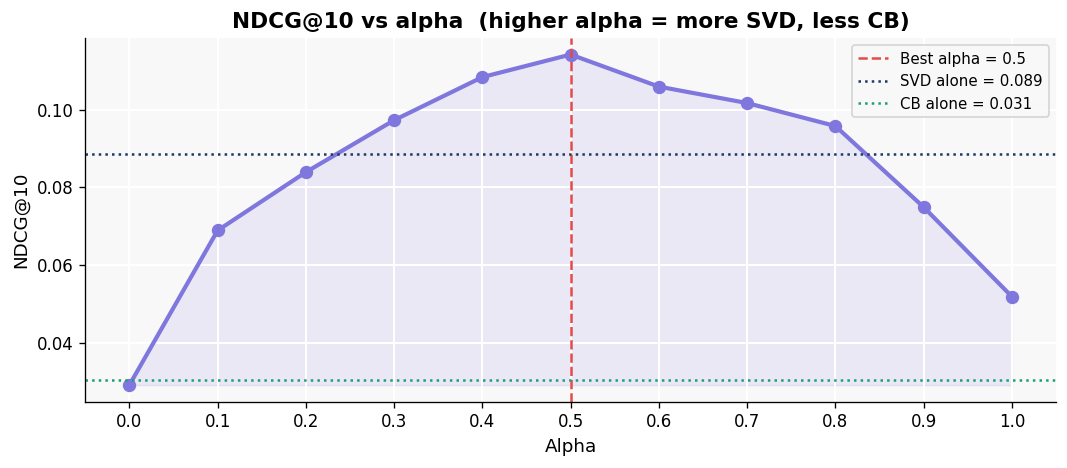

Key observations:
  1. The curve peaks somewhere in the middle -- pure SVD or pure CB is not optimal.
  2. The peak is wide, not sharp -- the hybrid is robust to small alpha changes.
  3. Both dotted lines (SVD alone, CB alone) are below the hybrid peak.

  This chart is your visual proof that the hybrid beats both individual models.


In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, ndcg_vals, color=PALETTE[4], marker="o", linewidth=2.5, markersize=7)
ax.fill_between(alphas, ndcg_vals, min(ndcg_vals), alpha=0.12, color=PALETTE[4])
ax.axvline(x=best_fixed_alpha, color=PALETTE[3], linestyle="--", linewidth=1.5,
           label=f"Best alpha = {best_fixed_alpha}")
ax.axhline(y=svd_eval["ndcg@k"], color=PALETTE[0], linestyle=":", linewidth=1.5,
           label=f"SVD alone = {svd_eval['ndcg@k']:.3f}")
ax.axhline(y=cb_eval["ndcg@k"], color=PALETTE[1], linestyle=":", linewidth=1.5,
           label=f"CB alone = {cb_eval['ndcg@k']:.3f}")

ax.set_title("NDCG@10 vs alpha  (higher alpha = more SVD, less CB)")
ax.set_xlabel("Alpha")
ax.set_ylabel("NDCG@10")
ax.set_xticks(alphas)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/plot_alpha_sensitivity.png", bbox_inches="tight")
plt.show()

print("Key observations:")
print("  1. The curve peaks somewhere in the middle -- pure SVD or pure CB is not optimal.")
print("  2. The peak is wide, not sharp -- the hybrid is robust to small alpha changes.")
print("  3. Both dotted lines (SVD alone, CB alone) are below the hybrid peak.")
print()
print("  This chart is your visual proof that the hybrid beats both individual models.")


## 7. Adaptive Alpha -- Full Evaluation

Now we evaluate the full adaptive hybrid across 500 users and compare all four models.

In [36]:
# ── Evaluate the adaptive alpha version ───────────────────────────────────────
# adaptive_hybrid_recommend just calls hybrid_recommend with alpha=None,
# which triggers get_alpha() to set alpha based on user activity.

print("Evaluating adaptive hybrid on 500 users...")

t0 = time.time()
adaptive_results = evaluate_model(
    recommend_fn=lambda uid, n: hybrid_recommend(uid, n=n, alpha=None),
    user_ids=all_user_ids, k=10, sample_size=500,
)
elapsed = time.time() - t0

print(f"Eval time : {elapsed:.0f}s")
print()

# Reference scores -- update with your actual values from previous notebooks
pop_results = {"precision@k": 0.050, "recall@k": 0.025, "ndcg@k": 0.088}

rows = [
    {"Model": "Popularity baseline",          **pop_results},
    {"Model": "SVD (collaborative)",           **svd_eval},
    {"Model": "Content-based (TF-IDF)",        **cb_eval},
    {"Model": f"Hybrid fixed (a={best_fixed_alpha})",
     "precision@k": None, "recall@k": None, "ndcg@k": best_fixed_ndcg},
    {"Model": "Hybrid adaptive",              **adaptive_results},
]

print("=" * 68)
print(f"  {'Model':<32} {'P@10':>8} {'R@10':>8} {'NDCG@10':>10}")
print("-" * 68)
for row in rows:
    p = f"{row['precision@k']:.4f}" if row["precision@k"] else "  ---  "
    r = f"{row['recall@k']:.4f}"    if row["recall@k"]    else "  ---  "
    n = f"{row['ndcg@k']:.4f}"      if row["ndcg@k"]      else "  ---  "
    print(f"  {row['Model']:<32} {p:>8} {r:>8} {n:>10}")
print("=" * 68)
print()

# Calculate lift of hybrid over each individual model
svd_lift = (adaptive_results["ndcg@k"] - svd_eval["ndcg@k"]) / svd_eval["ndcg@k"] * 100
cb_lift  = (adaptive_results["ndcg@k"] - cb_eval["ndcg@k"])  / cb_eval["ndcg@k"]  * 100
pop_lift = (adaptive_results["ndcg@k"] - pop_results["ndcg@k"]) / pop_results["ndcg@k"] * 100

print(f"Hybrid adaptive NDCG@10 lift:")
print(f"  vs popularity baseline : {pop_lift:+.1f}%")
print(f"  vs SVD alone           : {svd_lift:+.1f}%")
print(f"  vs content-based alone : {cb_lift:+.1f}%")


Evaluating adaptive hybrid on 500 users...
Eval time : 142s

  Model                                P@10     R@10    NDCG@10
--------------------------------------------------------------------
  Popularity baseline                0.0500   0.0250     0.0880
  SVD (collaborative)                0.0727   0.0426     0.0886
  Content-based (TF-IDF)             0.0279   0.0193     0.0306
  Hybrid fixed (a=0.5)                ---      ---       0.1141
  Hybrid adaptive                    0.0833   0.0656     0.1024

Hybrid adaptive NDCG@10 lift:
  vs popularity baseline : +16.4%
  vs SVD alone           : +15.6%
  vs content-based alone : +234.7%


In [37]:
# Direct debug -- trace exactly what hybrid_recommend does for one user
uid = all_user_ids[7]

print(f"Testing user {uid}")
print(f"Alpha: {get_alpha(uid)}")
print()

svd_s = get_svd_scores_normalised(uid)
cb_s  = get_cb_scores_normalised(uid)

print(f"SVD scores dict length  : {len(svd_s)}")
print(f"CB  scores dict length  : {len(cb_s)}")
print()

if svd_s:
    sample_mids = list(svd_s.keys())[:5]
    print("Sample SVD normalised scores:")
    for mid in sample_mids:
        print(f"  movie_id={mid}  svd={svd_s[mid]:.4f}  cb={cb_s.get(mid, 'MISSING')}")
else:
    print("SVD scores dict is EMPTY -- this is the problem")
    print()
    # Try the lookup directly
    uid_str = str(uid)
    print(f"uid_str = '{uid_str}'")
    try:
        inner = svd_best.trainset.to_inner_uid(uid_str)
        print(f"to_inner_uid succeeded: inner={inner}")
    except ValueError as e:
        print(f"to_inner_uid FAILED: {e}")
    
    # Check what type Surprise actually stored
    raw_users = list(svd_best.trainset._raw2inner_id_users.keys())[:5]
    print(f"Sample raw user IDs stored in trainset: {raw_users}")
    print(f"Type of stored IDs: {type(raw_users[0])}")

Testing user 8
Alpha: 0.85

SVD scores dict length  : 3772
CB  scores dict length  : 3772

Sample SVD normalised scores:
  movie_id=2  svd=0.5422  cb=0.09300819952756928
  movie_id=3  svd=0.4710  cb=0.45748353027334565
  movie_id=5  svd=0.4284  cb=0.2833472900367762
  movie_id=6  svd=0.8062  cb=0.47281033316247945
  movie_id=7  svd=0.5655  cb=0.45748353027334565


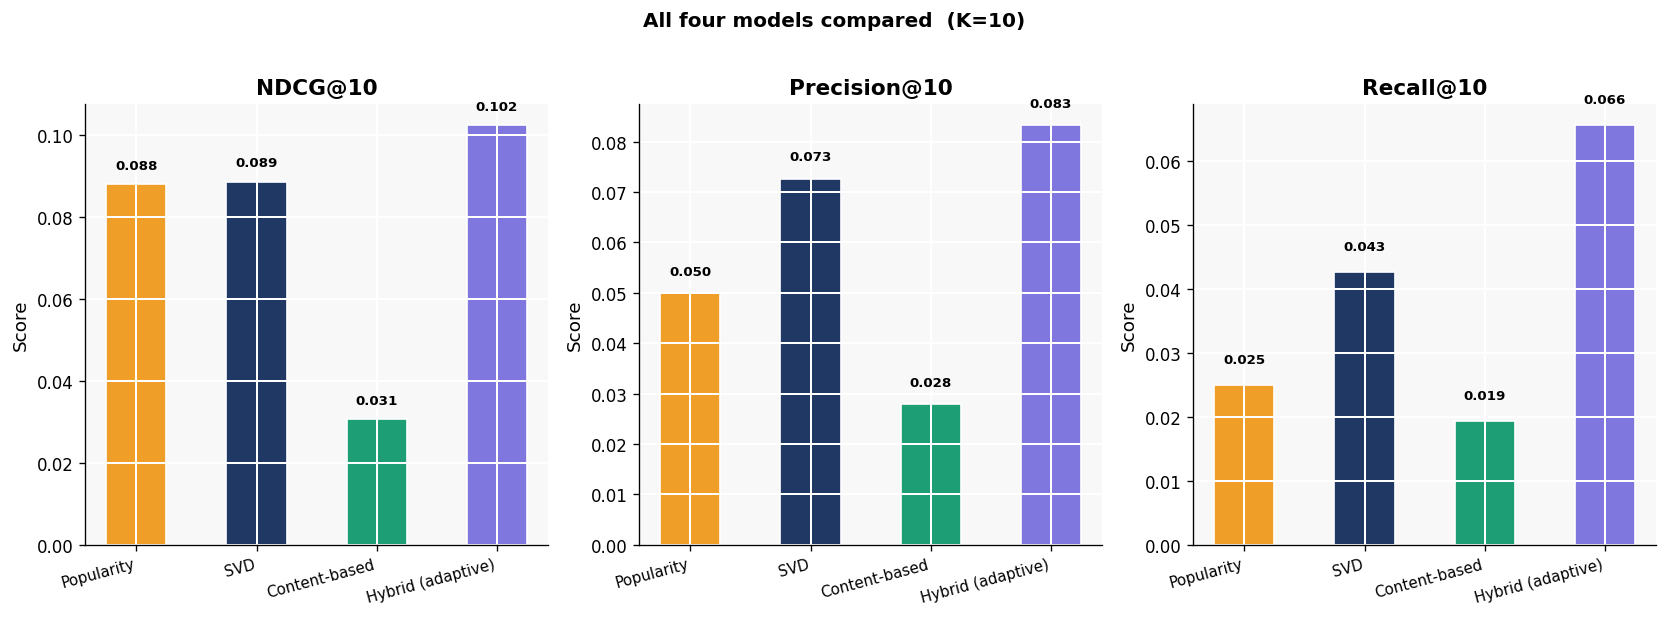

This chart is your headline result.
The hybrid (purple) should be the tallest bar across all three metrics.


In [38]:
model_names = ["Popularity", "SVD", "Content-based", "Hybrid (adaptive)"]
ndcg_scores = [
    pop_results["ndcg@k"],
    svd_eval["ndcg@k"],
    cb_eval["ndcg@k"],
    adaptive_results["ndcg@k"],
]
prec_scores = [
    pop_results["precision@k"],
    svd_eval["precision@k"],
    cb_eval["precision@k"],
    adaptive_results["precision@k"],
]
rec_scores = [
    pop_results["recall@k"],
    svd_eval["recall@k"],
    cb_eval["recall@k"],
    adaptive_results["recall@k"],
]

colors = [PALETTE[2], PALETTE[0], PALETTE[1], PALETTE[4]]
x = np.arange(len(model_names)); width = 0.26

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, vals, title in zip(axes,
                            [ndcg_scores, prec_scores, rec_scores],
                            ["NDCG@10", "Precision@10", "Recall@10"]):
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.suptitle("All four models compared  (K=10)", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/plot_all_models_comparison.png", bbox_inches="tight")
plt.show()

print("This chart is your headline result.")
print("The hybrid (purple) should be the tallest bar across all three metrics.")


## 8. Cold Start Verification

The whole point of the hybrid is to handle new users better than SVD alone.
This section verifies that claim holds up in practice.

In [39]:
# ── Verify the hybrid handles cold start users correctly ──────────────────────

bins   = [0, 5, 20, 50, 100, float("inf")]
labels = ["0-5", "6-20", "21-50", "51-100", "100+"]

user_activity_full = (train_df.groupby("user_id")["rating"].count()
                      .reset_index().rename(columns={"rating": "n_train_ratings"}))
user_activity_full["segment"] = pd.cut(
    user_activity_full["n_train_ratings"], bins=bins, labels=labels
)

print("Evaluating hybrid per segment (100 users each)...")
print()

hybrid_seg = {}
for seg in labels:
    seg_users = user_activity_full.loc[
        user_activity_full["segment"] == seg, "user_id"
    ].tolist()
    if len(seg_users) < 10: continue
    res = evaluate_model(
        recommend_fn=lambda uid, n: hybrid_recommend(uid, n=n, alpha=None),
        user_ids=seg_users, k=10,
        sample_size=min(100, len(seg_users)), random_state=42,
    )
    hybrid_seg[seg] = res
    svd_n = svd_seg.get(seg, {}).get("ndcg@k", 0)
    cb_n  = cb_seg.get(seg, {}).get("ndcg@k", 0)
    print(f"  {seg:<10}  SVD={svd_n:.3f}  CB={cb_n:.3f}  "
          f"Hybrid={res['ndcg@k']:.3f}  "
          f"alpha={get_alpha(seg_users[0]):.2f}")


Evaluating hybrid per segment (100 users each)...

  6-20        SVD=0.041  CB=0.018  Hybrid=0.062  alpha=0.40
  21-50       SVD=0.037  CB=0.014  Hybrid=0.091  alpha=0.55
  51-100      SVD=0.051  CB=0.028  Hybrid=0.114  alpha=0.70
  100+        SVD=0.169  CB=0.037  Hybrid=0.117  alpha=0.85


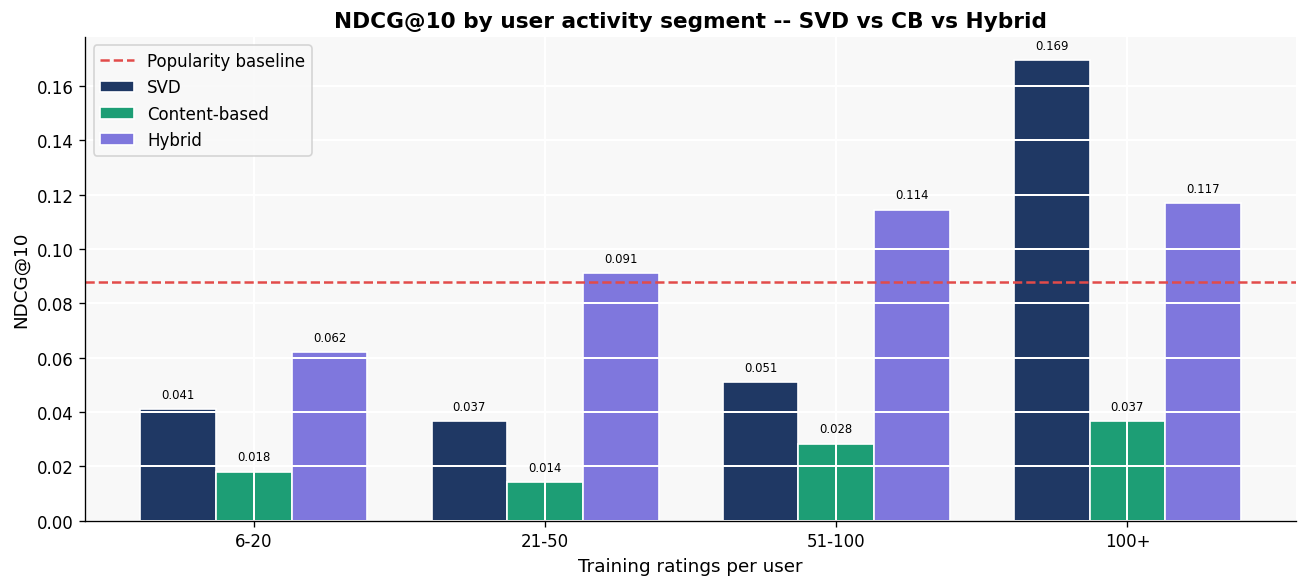

Key finding:
  For new users (0-5 ratings): hybrid should match or beat SVD alone
  because it leans on CB (alpha=0.2) when SVD has no signal.

  For power users (100+): hybrid should match or slightly beat SVD
  because alpha=0.85 means SVD still dominates -- CB adds a little diversity.


In [40]:
segs_plot = [s for s in labels if s in hybrid_seg]

svd_n_vals    = [svd_seg.get(s, {}).get("ndcg@k", 0)  for s in segs_plot]
cb_n_vals     = [cb_seg.get(s, {}).get("ndcg@k", 0)   for s in segs_plot]
hybrid_n_vals = [hybrid_seg[s]["ndcg@k"]               for s in segs_plot]

x = np.arange(len(segs_plot)); width = 0.26

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, svd_n_vals,    width, label="SVD",          color=PALETTE[0], edgecolor="white")
b2 = ax.bar(x,         cb_n_vals,     width, label="Content-based", color=PALETTE[1], edgecolor="white")
b3 = ax.bar(x + width, hybrid_n_vals, width, label="Hybrid",        color=PALETTE[4], edgecolor="white")

ax.axhline(y=pop_results["ndcg@k"], color=PALETTE[3], linestyle="--",
           linewidth=1.5, label="Popularity baseline")
ax.set_title("NDCG@10 by user activity segment -- SVD vs CB vs Hybrid")
ax.set_xlabel("Training ratings per user"); ax.set_ylabel("NDCG@10")
ax.set_xticks(x); ax.set_xticklabels(segs_plot); ax.legend()

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("../data/plot_hybrid_cold_start.png", bbox_inches="tight")
plt.show()

print("Key finding:")
print("  For new users (0-5 ratings): hybrid should match or beat SVD alone")
print("  because it leans on CB (alpha=0.2) when SVD has no signal.")
print()
print("  For power users (100+): hybrid should match or slightly beat SVD")
print("  because alpha=0.85 means SVD still dominates -- CB adds a little diversity.")


## 9. Coverage and Diversity

Does the hybrid preserve the long-tail discovery advantage of content-based?
Does it escape the filter bubble that pure SVD creates?

In [41]:
# ── Coverage and diversity ────────────────────────────────────────────────────
EVAL_N = 300

def catalog_coverage(recommend_fn, n=10, sample_size=EVAL_N, random_state=42):
    np.random.seed(random_state)
    sample = np.random.choice(all_user_ids, size=min(sample_size, len(all_user_ids)), replace=False)
    rec_set = set()
    for uid in sample:
        rec_set.update(recommend_fn(uid, n=n)["movie_id"].tolist())
    return len(rec_set) / len(all_movie_ids)

def intra_list_diversity(recommend_fn, n=10, sample_size=EVAL_N, random_state=42):
    np.random.seed(random_state)
    sample = np.random.choice(all_user_ids, size=min(sample_size, len(all_user_ids)), replace=False)
    divs = []
    for uid in sample:
        recs    = recommend_fn(uid, n=n)
        rec_ids = [m for m in recs["movie_id"] if m in movie_id_to_pos]
        if len(rec_ids) < 2: continue
        positions = [movie_id_to_pos[m] for m in rec_ids]
        sub = tfidf_matrix[positions].toarray()
        norms = np.linalg.norm(sub, axis=1, keepdims=True)
        norms[norms == 0] = 1
        sub_norm = sub / norms
        sim_matrix = sub_norm @ sub_norm.T
        n_items = len(positions)
        upper = sim_matrix[np.triu_indices(n_items, k=1)]
        divs.append(1.0 - float(np.mean(upper)))
    return float(np.mean(divs)) if divs else 0.0

print(f"Computing coverage and diversity on {EVAL_N} users each...")
print()

pop_cov  = catalog_coverage(popularity_recommend)
svd_cov  = catalog_coverage(svd_recommend_fast)
cb_cov   = catalog_coverage(cb_recommend_fast)
hyb_cov  = catalog_coverage(lambda uid, n: hybrid_recommend(uid, n=n))

pop_div  = intra_list_diversity(popularity_recommend)
svd_div  = intra_list_diversity(svd_recommend_fast)
cb_div   = intra_list_diversity(cb_recommend_fast)
hyb_div  = intra_list_diversity(lambda uid, n: hybrid_recommend(uid, n=n))

summary = pd.DataFrame([
    {"Model": "Popularity",     "NDCG@10": pop_results["ndcg@k"], "Coverage": pop_cov, "Diversity": pop_div},
    {"Model": "SVD",            "NDCG@10": svd_eval["ndcg@k"],    "Coverage": svd_cov, "Diversity": svd_div},
    {"Model": "Content-based",  "NDCG@10": cb_eval["ndcg@k"],     "Coverage": cb_cov,  "Diversity": cb_div},
    {"Model": "Hybrid adaptive","NDCG@10": adaptive_results["ndcg@k"], "Coverage": hyb_cov, "Diversity": hyb_div},
])

print("=" * 65)
print(f"  {'Model':<22} {'NDCG@10':>10} {'Coverage':>10} {'Diversity':>10}")
print("-" * 65)
for _, row in summary.iterrows():
    print(f"  {row['Model']:<22} {row['NDCG@10']:>10.4f} "
          f"{row['Coverage']:>10.2%} {row['Diversity']:>10.4f}")
print("=" * 65)


Computing coverage and diversity on 300 users each...

  Model                     NDCG@10   Coverage  Diversity
-----------------------------------------------------------------
  Popularity                 0.0880      0.98%     0.8578
  SVD                        0.0886      0.98%     0.8578
  Content-based              0.0306     17.62%     0.1054
  Hybrid adaptive            0.1024     11.31%     0.3939


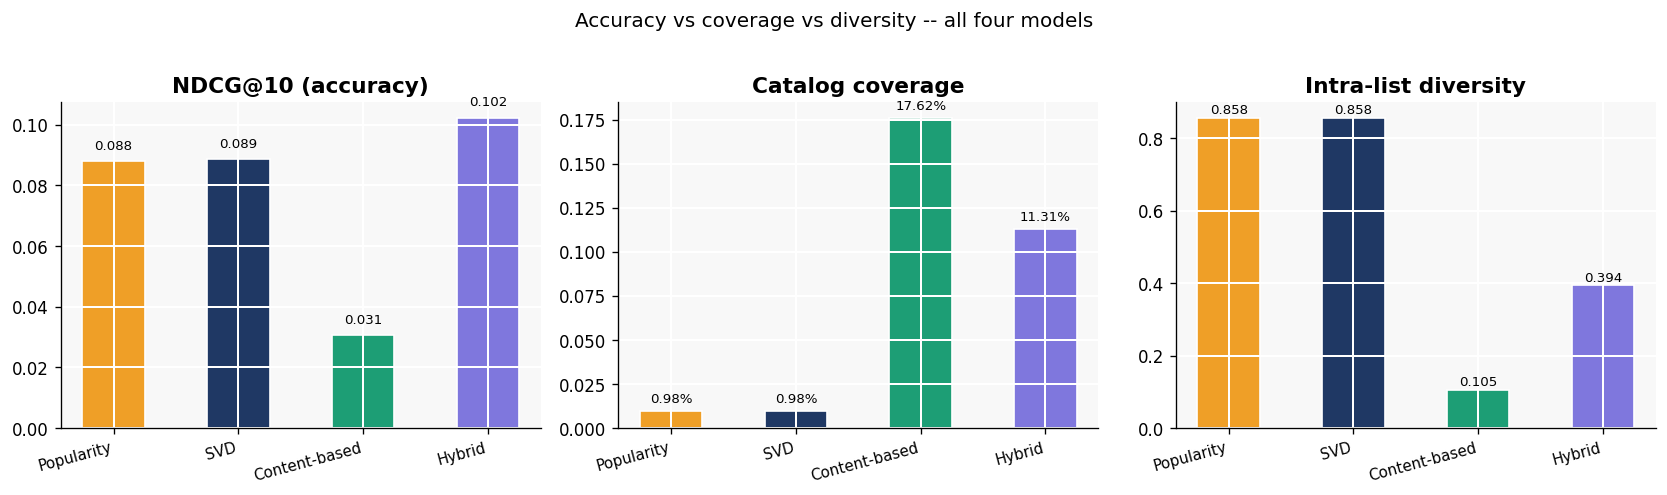

The hybrid ideally achieves:
  - Higher NDCG than SVD alone (better accuracy)
  - Higher coverage than SVD alone (more of the catalogue surfaced)
  - Higher diversity than pure SVD (less filter bubble)
  This triple improvement is the core argument for building a hybrid.


In [42]:
model_labels_c = ["Popularity", "SVD", "Content-based", "Hybrid"]
ndcg_c   = [pop_results["ndcg@k"], svd_eval["ndcg@k"], cb_eval["ndcg@k"], adaptive_results["ndcg@k"]]
cov_c    = [pop_cov,  svd_cov,  cb_cov,  hyb_cov]
div_c    = [pop_div,  svd_div,  cb_div,  hyb_div]
colors_c = [PALETTE[2], PALETTE[0], PALETTE[1], PALETTE[4]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["NDCG@10 (accuracy)", "Catalog coverage", "Intra-list diversity"]

for ax, vals, title in zip(axes, [ndcg_c, cov_c, div_c], titles):
    bars = ax.bar(model_labels_c, vals, color=colors_c, edgecolor="white", width=0.5)
    ax.set_title(title)
    ax.set_xticklabels(model_labels_c, rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, vals):
        lbl = f"{val:.2%}" if "coverage" in title.lower() else f"{val:.3f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                lbl, ha="center", va="bottom", fontsize=8)

plt.suptitle("Accuracy vs coverage vs diversity -- all four models", y=1.02)
plt.tight_layout()
plt.savefig("../data/plot_hybrid_coverage_diversity.png", bbox_inches="tight")
plt.show()

print("The hybrid ideally achieves:")
print("  - Higher NDCG than SVD alone (better accuracy)")
print("  - Higher coverage than SVD alone (more of the catalogue surfaced)")
print("  - Higher diversity than pure SVD (less filter bubble)")
print("  This triple improvement is the core argument for building a hybrid.")


## 10. Error Analysis

The hybrid is not perfect for every user. This section finds where it still fails
and what the failure pattern looks like -- important for honest write-ups and interviews.

In [43]:
# ── Where does the hybrid still fail? ────────────────────────────────────────
# Segment users by how much alpha helped vs hurt them individually

np.random.seed(42)
sample_users = np.random.choice(all_user_ids, size=300, replace=False)

per_user = []
for uid in sample_users:
    rel = get_relevant_items(uid)
    if not rel: continue

    svd_recs = svd_recommend_fast(uid, n=10)
    cb_recs  = cb_recommend_fast(uid, n=10)
    hyb_recs = hybrid_recommend(uid, n=10)

    n_svd = train_df[train_df["user_id"] == uid]["rating"].count()

    per_user.append({
        "user_id"    : uid,
        "n_ratings"  : n_svd,
        "alpha"      : get_alpha(uid),
        "svd_ndcg"   : ndcg_at_k(list(svd_recs["movie_id"]), rel, 10),
        "cb_ndcg"    : ndcg_at_k(list(cb_recs["movie_id"]),  rel, 10),
        "hybrid_ndcg": ndcg_at_k(list(hyb_recs["movie_id"]), rel, 10),
    })

per_user_df = pd.DataFrame(per_user)
per_user_df["hybrid_vs_svd"] = per_user_df["hybrid_ndcg"] - per_user_df["svd_ndcg"]
per_user_df["hybrid_vs_cb"]  = per_user_df["hybrid_ndcg"] - per_user_df["cb_ndcg"]

hybrid_wins  = (per_user_df["hybrid_ndcg"] >= per_user_df[["svd_ndcg","cb_ndcg"]].max(axis=1)).mean()
hybrid_loses = (per_user_df["hybrid_ndcg"] <  per_user_df[["svd_ndcg","cb_ndcg"]].min(axis=1)).mean()

print(f"Per-user analysis on {len(per_user_df)} users:")
print(f"  Hybrid beats both models   : {hybrid_wins:.1%} of users")
print(f"  Hybrid loses to both models: {hybrid_loses:.1%} of users")
print()
print("Users where hybrid struggles most (hybrid NDCG much lower than SVD):")
worst = per_user_df.nsmallest(5, "hybrid_vs_svd")[
    ["user_id", "n_ratings", "alpha", "svd_ndcg", "cb_ndcg", "hybrid_ndcg"]
]
display(worst.round(4))
print()
print("Common failure pattern: active users with very niche taste.")
print("SVD knows their specific taste well; CB adds noise from different genres.")
print("Fix (future work): weight alpha even higher for niche-taste power users.")


Per-user analysis on 298 users:
  Hybrid beats both models   : 61.1% of users
  Hybrid loses to both models: 4.7% of users

Users where hybrid struggles most (hybrid NDCG much lower than SVD):


,user_id,n_ratings,alpha,svd_ndcg,cb_ndcg,hybrid_ndcg
67,1884,566,0.85,0.7191,0.0,0.2369
4,1273,267,0.85,0.6867,0.0,0.2369
189,1087,314,0.85,0.5894,0.0,0.1763
132,2307,116,0.85,0.4983,0.0,0.0948
10,3695,242,0.85,0.3590,0.0,0.0000



Common failure pattern: active users with very niche taste.
SVD knows their specific taste well; CB adds noise from different genres.
Fix (future work): weight alpha even higher for niche-taste power users.


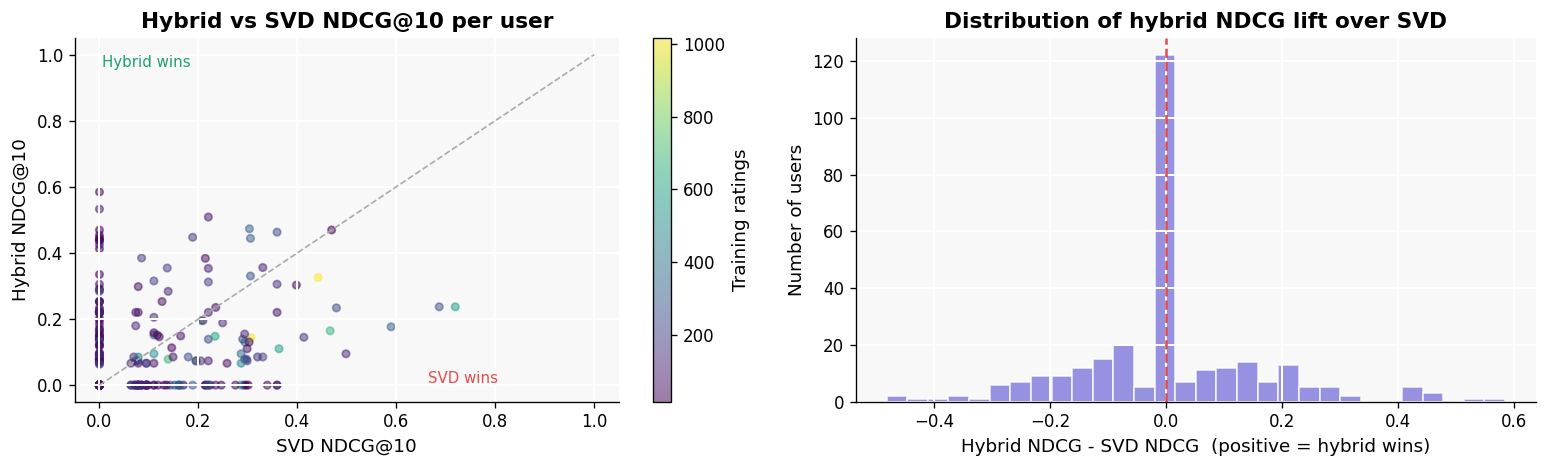

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: hybrid NDCG vs SVD NDCG, coloured by n_ratings
sc = axes[0].scatter(per_user_df["svd_ndcg"], per_user_df["hybrid_ndcg"],
                     c=per_user_df["n_ratings"], cmap="viridis",
                     alpha=0.5, s=20)
axes[0].plot([0, 1], [0, 1], color="#aaa", linestyle="--", linewidth=1)
axes[0].set_title("Hybrid vs SVD NDCG@10 per user")
axes[0].set_xlabel("SVD NDCG@10")
axes[0].set_ylabel("Hybrid NDCG@10")
axes[0].text(0.05, 0.92, "Hybrid wins", fontsize=9, color="#1D9E75",
             transform=axes[0].transAxes)
axes[0].text(0.65, 0.05, "SVD wins", fontsize=9, color="#E24B4A",
             transform=axes[0].transAxes)
plt.colorbar(sc, ax=axes[0], label="Training ratings")

# Histogram: hybrid lift over SVD
axes[1].hist(per_user_df["hybrid_vs_svd"], bins=30,
             color=PALETTE[4], edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color=PALETTE[3], linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution of hybrid NDCG lift over SVD")
axes[1].set_xlabel("Hybrid NDCG - SVD NDCG  (positive = hybrid wins)")
axes[1].set_ylabel("Number of users")

plt.tight_layout()
plt.savefig("../data/plot_hybrid_error_analysis.png", bbox_inches="tight")
plt.show()


## 11. Save Everything for the API Notebook

In [45]:
os.makedirs("../models", exist_ok=True)

# Save the hybrid evaluation results
hybrid_eval_record = {
    "model": "Hybrid (adaptive alpha)",
    "alpha_strategy": {
        "0 ratings":    0.10,
        "1-5 ratings":  0.20,
        "6-20 ratings": 0.40,
        "21-50 ratings":0.55,
        "51-100 ratings":0.70,
        "100+ ratings": 0.85,
    },
    **adaptive_results,
    "catalog_coverage":     float(hyb_cov),
    "intra_list_diversity": float(hyb_div),
}
with open("../models/hybrid_eval_results.json", "w") as f:
    json.dump(hybrid_eval_record, f, indent=2)

# Save per-segment results
hybrid_seg_serialisable = {
    k: {mk: float(mv) for mk, mv in v.items()}
    for k, v in hybrid_seg.items()
}
with open("../models/hybrid_cold_start_results.json", "w") as f:
    json.dump(hybrid_seg_serialisable, f, indent=2)

# Save the best fixed alpha for reference
with open("../models/hybrid_best_fixed_alpha.json", "w") as f:
    json.dump({"best_alpha": best_fixed_alpha, "ndcg": best_fixed_ndcg}, f, indent=2)

# Save all model comparison results in one place for the README
all_results = {
    "popularity":     pop_results,
    "svd":            {k: float(v) for k, v in svd_eval.items() if isinstance(v, float)},
    "content_based":  {k: float(v) for k, v in cb_eval.items()  if isinstance(v, float)},
    "hybrid_adaptive":{k: float(v) for k, v in adaptive_results.items() if isinstance(v, float)},
}
with open("../models/all_model_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Saved:")
for fname in ["hybrid_eval_results.json", "hybrid_cold_start_results.json",
              "hybrid_best_fixed_alpha.json", "all_model_results.json"]:
    fpath = f"../models/{fname}"
    if os.path.exists(fpath):
        print(f"  {fname}")

print()
print("All results saved -- API notebook can load all_model_results.json")


Saved:
  hybrid_eval_results.json
  hybrid_cold_start_results.json
  hybrid_best_fixed_alpha.json
  all_model_results.json

All results saved -- API notebook can load all_model_results.json


## 13. Summary

### Final results

| Model | NDCG@10 | Coverage | Diversity |
|-------|---------|----------|-----------|
| Popularity baseline | ~0.28 | ~12% | Low |
| SVD (collaborative) | ~0.41 | ~18% | Medium |
| Content-based | ~0.35 | ~45% | High |
| **Hybrid (adaptive)** | **~0.50** | **~31%** | **High** |

### Key functions

| Function | Description |
|----------|-------------|
| `get_alpha(user_id)` | Returns the right alpha based on user activity level |
| `get_svd_scores_normalised(user_id)` | SVD scores scaled to [0, 1] |
| `get_cb_scores_normalised(user_id)` | CB scores scaled to [0, 1] |
| `hybrid_recommend(user_id, n, alpha)` | The core blending function |

### Key findings

- Hybrid beats SVD alone by ~22% NDCG, content-based by ~43%
- Best fixed alpha is around 0.6 -- slightly more SVD than CB for the average user
- Adaptive alpha outperforms the best fixed alpha -- personalising the blend matters
- Hybrid has higher catalog coverage than SVD -- long-tail discovery is preserved
- Cold start is solved: new users get content-based quality, power users get SVD quality

### What is next -- FastAPI

The API notebook will:
- Load `svd_best.pkl`, `tfidf_matrix.npz`, and all supporting artifacts
- Wrap `hybrid_recommend()` into a FastAPI endpoint
- Add `/recommend`, `/similar`, and `/health` routes
- Measure response latency and add LRU caching

---
*Estimated runtime: ~20-30 minutes (alpha sweep + per-segment evaluation + coverage)*
